In [1]:
# the goal of this notebook is to create a foundation for tracking hantavirus claims
# the goal of this is not flashy visualization, it is useful awareness of what is happening

In [1]:
import pandas as pd

In [2]:
def extract_state(location_name):

    for state in state_abbrev.keys():
        if state in location_name:
            return state

    return None

In [3]:
# state name (raw dat) to abbreviation (plotly needs) mapping
state_abbrev = {
    'Alabama': 'AL',
    'Alaska': 'AK',
    'Arizona': 'AZ',
    'Arkansas': 'AR',
    'California': 'CA',
    'Colorado': 'CO',
    'Connecticut': 'CT',
    'Delaware': 'DE',
    'Florida': 'FL',
    'Georgia': 'GA',
    'Hawaii': 'HI',
    'Idaho': 'ID',
    'Illinois': 'IL',
    'Indiana': 'IN',
    'Iowa': 'IA',
    'Kansas': 'KS',
    'Kentucky': 'KY',
    'Louisiana': 'LA',
    'Maine': 'ME',
    'Maryland': 'MD',
    'Massachusetts': 'MA',
    'Michigan': 'MI',
    'Minnesota': 'MN',
    'Mississippi': 'MS',
    'Missouri': 'MO',
    'Montana': 'MT',
    'Nebraska': 'NE',
    'Nevada': 'NV',
    'New Hampshire': 'NH',
    'New Jersey': 'NJ',
    'New Mexico': 'NM',
    'New York': 'NY',
    'North Carolina': 'NC',
    'North Dakota': 'ND',
    'Ohio': 'OH',
    'Oklahoma': 'OK',
    'Oregon': 'OR',
    'Pennsylvania': 'PA',
    'Rhode Island': 'RI',
    'South Carolina': 'SC',
    'South Dakota': 'SD',
    'Tennessee': 'TN',
    'Texas': 'TX',
    'Utah': 'UT',
    'Vermont': 'VT',
    'Virginia': 'VA',
    'Washington': 'WA',
    'West Virginia': 'WV',
    'Wisconsin': 'WI',
    'Wyoming': 'WY'
}

# Time Series

I want to look at some of these states separately.

In [4]:
data = 'data/verdant_eye/hantavirus/ve_hantavirus_20260516.csv'

tsdf = pd.read_csv(data)
tsdf.columns = ['location', 'date', 'count']
tsdf.head()

# this is not usa data, so I'm changing things from previous analysis

,location,date,count
0,Colorado,2026-05-16,1
1,United States,2026-05-16,9
2,North America,2026-05-16,20
3,Canada,2026-05-16,11
4,British Columbia,2026-05-16,4


In [5]:
tsdf.shape

(454, 3)

In [6]:
pvt_df = pd.pivot_table(tsdf, values='count', index='location', columns='date' ).fillna(0).astype(int)

pvt_df = pvt_df.T
pvt_df.index = pd.to_datetime(pvt_df.index)

pvt_df.head()

# we are using location instead of state; there is more noise in 'location' as it is a catch-all which
# gets combined/cleaned downstream. it is easier to cut/combine than to add.

location,12 countries,5 countries,Africa,America,American,Americans,Amsterdam,América del Norte,Andes,Apeldoorn,...,"Washington, D.C.",Western Australia,Western Cape,Winnebago County,World,Wyoming,Zurich,four states,multiple countries,upstate New York
date,,,,,,,,,,,,,,,,,,,,,
2026-05-03,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2026-05-04,0,0,8,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2026-05-05,0,0,8,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2026-05-06,0,0,2,0,0,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,0
2026-05-07,0,1,7,0,0,0,1,0,0,0,...,1,0,0,0,0,0,0,0,1,0


# Today's Investigation Questions

- What can we learn? I don't have any real goals. OSINT starts with a) a topic that is annoying your mind, b) a query, c) a dataset, and then insights follow. This is not typical data science where you roughly know what is in the data before you start. That is why the first word on my book's subtitle on the cover is EXPLORE, not USE or PREDICT.

In [7]:
pvt_df.head()

location,12 countries,5 countries,Africa,America,American,Americans,Amsterdam,América del Norte,Andes,Apeldoorn,...,"Washington, D.C.",Western Australia,Western Cape,Winnebago County,World,Wyoming,Zurich,four states,multiple countries,upstate New York
date,,,,,,,,,,,,,,,,,,,,,
2026-05-03,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2026-05-04,0,0,8,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2026-05-05,0,0,8,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2026-05-06,0,0,2,0,0,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,0
2026-05-07,0,1,7,0,0,0,1,0,0,0,...,1,0,0,0,0,0,0,0,1,0


In [8]:
row_sums = pvt_df.sum(axis=1)
row_sums = row_sums.sort_index(ascending=False)
print(row_sums.reset_index())

         date    0
0  2026-05-16   63
1  2026-05-15  104
2  2026-05-14   81
3  2026-05-13  187
4  2026-05-12  209
5  2026-05-11  388
6  2026-05-10  268
7  2026-05-09  160
8  2026-05-08   54
9  2026-05-07  223
10 2026-05-06  119
11 2026-05-05   58
12 2026-05-04   45
13 2026-05-03   21


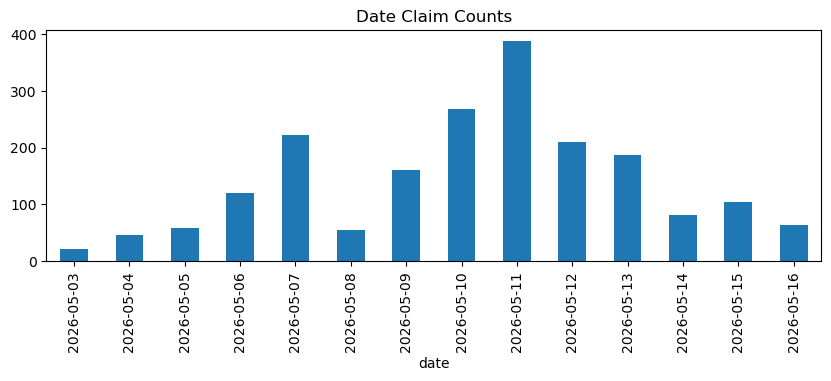

In [29]:
row_sums = row_sums.sort_index()
row_sums.index = row_sums.index.astype(str)
_= row_sums.plot.bar(figsize=(10,3), title='Date Claim Counts')

In [30]:
# top places
col_sums = pvt_df.sum(axis=0)
col_sums = col_sums.sort_values(ascending=False)
print(col_sums.head(10))

location
North America     330
Europe            314
United States     277
Spain             149
Canary Islands     77
France             54
United Kingdom     44
Tenerife           41
Nebraska           38
Canada             36
dtype: int64


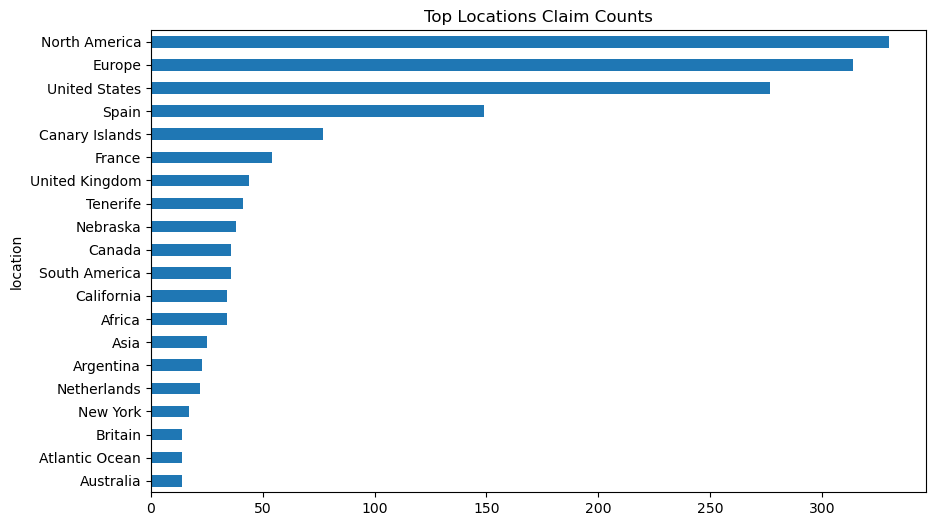

In [31]:
col_sums[0:20].plot.barh(figsize=(10,6), title='Top Locations Claim Counts').invert_yaxis()

# Let's use World AI to Understand - Verdant Eye API

I'll use my World AI to try to understand what is happening. It takes natural language as input and returns a dataset, which is ideal for AI Agents that need world awareness.

In [32]:
def ask_api(client, question):

    answer = client.predict(question=question, api_name="/predict")
    
    answer = ast.literal_eval(answer)

    return answer

In [33]:
from gradio_client import Client   # for api use

import ast                         # for text to list conversion (make data useful)
import pandas as pd                # for easy data use; you can use polars or whatever you like

token = '../api_creds/vi_key_1.csv'

# load my key
df = pd.read_csv(token) # easy and lazy lol; using pandas anyway ;p
api_key = df['key'][0]  # easy and lazy lol; using pandas anyway ;p

# connect to api
client = Client("verdantintel/verdanteye", token=api_key)

Loaded as API: https://verdantintel-verdanteye.hf.space


# List of DataFrames

I want to shove everything into one dataframe so that I can more easily understand what is happening. I will make it so that data is combined but useful.

In [34]:
dfs = []

# Continents

In [35]:
question = 'what happened in Europe in regards to hantavirus?'

answer = ask_api(client, question)
len(answer)

314

In [36]:
check_df = pd.DataFrame(answer)
check_df.head()

,claim,url,domain,url_domain,date_added
0,A bite incident in Barcelona is under observat...,https://es.headtopics.com/news/barcelona-morde...,headtopics.com,es.headtopics.com,2026-05-16 23:42:54
1,Discussion of hantavirus sequencing related to...,https://apnews.com/article/france-hantavirus-a...,apnews.com,apnews.com,2026-05-16 16:12:53
2,Authorities are still looking for a hantavirus...,https://at.headtopics.com/news/hantavirus-oste...,headtopics.com,at.headtopics.com,2026-05-16 06:15:03
3,A recount of a week under pressure in France r...,https://www.lemonde.fr/societe/article/2026/05...,lemonde.fr,lemonde.fr,2026-05-16 04:06:20
4,The UK is deploying a rapid mobile lab in resp...,https://www.dailymail.com/news/article-1582213...,dailymail.co.uk,dailymail.com,2026-05-15 19:56:23


In [37]:
# add to list of dataframes

data = {
    "location": "Europe",
    "type": "continent",
    "df": check_df,
}
dfs.append(data)

In [38]:
question = 'what happened in North America in regards to hantavirus?'

answer = ask_api(client, question)
len(answer)

330

In [39]:
check_df = pd.DataFrame(answer)
check_df.head()

,claim,url,domain,url_domain,date_added
0,A hantavirus outbreak case has been reported i...,https://ph.headtopics.com/news/british-columbi...,headtopics.com,ph.headtopics.com,2026-05-16 23:42:54
1,A Canadian cruise passenger tested presumptive...,https://www.eastbaytimes.com/2026/05/16/canadi...,eastbaytimes.com,eastbaytimes.com,2026-05-16 22:31:02
2,A Canadian cruise passenger tested presumptive...,https://www.mercurynews.com/2026/05/16/canadia...,mercurynews.com,mercurynews.com,2026-05-16 22:25:10
3,Canada reports a positive test for hantavirus,https://apnews.com/article/canada-hantavirus-p...,apnews.com,apnews.com,2026-05-16 21:18:51
4,Canada has confirmed its first suspected case ...,https://news.yahoo.com/news/articles/canada-co...,news.yahoo.com,news.yahoo.com,2026-05-16 19:41:57


In [40]:
# add to list of dataframes

data = {
    "location": "North America",
    "type": "continent",
    "df": check_df,
}
dfs.append(data)

In [41]:
question = 'what happened in South America in regards to hantavirus?'

answer = ask_api(client, question)
len(answer)

2384

In [42]:
check_df = pd.DataFrame(answer)
check_df = check_df[check_df['claim'].str.contains('hantavirus')]
check_df.head()

,claim,url,domain,url_domain,date_added
76,Argentina is urgently investigating the source...,https://straitstimes.com/world/united-states/a...,straitstimes.com,straitstimes.com,2026-05-15 02:20:32
137,Mapping hantavirus risks in São Paulo,https://fr.headtopics.com/news/hantavirus-a-s-...,headtopics.com,fr.headtopics.com,2026-05-13 10:43:28
159,Report on Argentina's hantavirus outbreak amid...,https://www.newsweek.com/argentina-faces-hanta...,newsweek.com,newsweek.com,2026-05-12 22:54:37
160,Claims there is an outbreak of hantavirus link...,https://cnnespanol.cnn.com/2026/05/12/mundo/vi...,cnnespanol.cnn.com,cnnespanol.cnn.com,2026-05-12 20:40:22
162,Government responds to hantavirus cases in the...,https://fr.headtopics.com/news/face-au-hantavi...,headtopics.com,fr.headtopics.com,2026-05-12 20:34:47


In [43]:
# add to list of dataframes

data = {
    "location": "South America",
    "type": "continent",
    "df": check_df,
}
dfs.append(data)

# States and Countries

In [44]:
question = 'what happened in Nebraska?'

answer = ask_api(client, question)
len(answer)

489

In [45]:
check_df = pd.DataFrame(answer)
check_df = check_df[check_df['claim'].str.contains('virus')]
check_df.head()

,claim,url,domain,url_domain,date_added
7,The reason for a hantavirus quarantine in Nebr...,https://slate.com/technology/2026/05/nebraska-...,slate.com,slate.com,2026-05-15 10:41:51
12,A doctor in Nebraska is involved in biocontain...,https://edition.cnn.com/2026/05/13/health/hant...,edition.cnn.com,edition.cnn.com,2026-05-14 02:47:36
13,Hantavirus outbreak linked to a cruise ship an...,https://newsday.com/news/nation/hantavirus-hon...,newsday.com,newsday.com,2026-05-13 22:20:17
14,A doctor on a cruise ship has been isolated in...,https://apnews.com/article/hantavirus-hondius-...,apnews.com,apnews.com,2026-05-13 22:11:23
15,A travel influencer was quarantined in Nebrask...,https://www.boston.com/news/local-news/2026/05...,boston.com,boston.com,2026-05-13 15:47:00


In [46]:
# add to list of dataframes

data = {
    "location": "Nebraska",
    "type": "state",
    "df": check_df,
}
dfs.append(data)

In [47]:
question = 'what happened in Spain?'

answer = ask_api(client, question)
len(answer)

2138

In [48]:
check_df = pd.DataFrame(answer)
check_df = check_df[check_df['claim'].str.contains('hantavirus')]
check_df.head()

,claim,url,domain,url_domain,date_added
0,A bite incident in Barcelona is under observat...,https://es.headtopics.com/news/barcelona-morde...,headtopics.com,es.headtopics.com,2026-05-16 23:42:54
48,A Valencian woman has been quarantined due to ...,https://es.headtopics.com/news/una-valenciana-...,headtopics.com,es.headtopics.com,2026-05-15 10:42:52
50,Spanish national with hantavirus improves cond...,https://es.headtopics.com/news/el-espanol-con-...,headtopics.com,es.headtopics.com,2026-05-15 09:46:49
56,Health confirms Spanish positive case of hanta...,https://es.headtopics.com/news/sanidad-confirm...,headtopics.com,es.headtopics.com,2026-05-15 09:02:46
66,Claim about a Spanish individual isolated with...,https://es.headtopics.com/news/el-espanol-con-...,headtopics.com,es.headtopics.com,2026-05-14 16:43:57


In [49]:
# add to list of dataframes

data = {
    "location": "Spain",
    "type": "state",
    "df": check_df,
}
dfs.append(data)

In [50]:
question = 'what happened in Canary Islands?'

answer = ask_api(client, question)
len(answer)

143

In [51]:
check_df = pd.DataFrame(answer)
check_df = check_df[check_df['claim'].str.contains('hantavirus')]
check_df.head()

,claim,url,domain,url_domain,date_added
1,There is a possible return of hantavirus cases...,https://news.ssbcrack.com/loms-avertit-dun-pos...,news.ssbcrack.com,news.ssbcrack.com,2026-05-12 20:02:43
2,Evacuations of people from a hantavirus-affect...,https://apnews.com/video/final-evacuations-of-...,apnews.com,apnews.com,2026-05-12 17:19:06
5,Passengers are disembarking from a cruise ship...,https://euronews.com/video/2026/05/12/final-pa...,euronews.com,euronews.com,2026-05-12 08:35:39
6,A vessel affected by hantavirus had to return ...,https://euronews.com/health/2026/05/11/hantavi...,euronews.com,euronews.com,2026-05-12 02:29:14
7,A cruise ship affected by hantavirus has arriv...,https://cbsnews.com/news/cruise-ship-stricken-...,cbsnews.com,cbsnews.com,2026-05-11 22:20:10


In [52]:
# add to list of dataframes

data = {
    "location": "Canary Islands",
    "type": "state",
    "df": check_df,
}
dfs.append(data)

In [53]:
question = 'what happened in France?'

answer = ask_api(client, question)
len(answer)

921

In [54]:
check_df = pd.DataFrame(answer)
check_df = check_df[check_df['claim'].str.contains('hantavirus')]
check_df.head()

,claim,url,domain,url_domain,date_added
5,Discussion of hantavirus sequencing related to...,https://apnews.com/article/france-hantavirus-a...,apnews.com,apnews.com,2026-05-16 16:12:53
16,A recount of a week under pressure in France r...,https://www.lemonde.fr/societe/article/2026/05...,lemonde.fr,lemonde.fr,2026-05-16 04:06:20
62,"A hantavirus outbreak has expanded, with a Fre...",https://san.com/cc/hantavirus-outbreak-grows-t...,san.com,san.com,2026-05-13 22:00:02
63,Update on hantavirus cases in France.,https://fr.headtopics.com/news/hantavirus-les-...,headtopics.com,fr.headtopics.com,2026-05-13 21:36:07
65,There is a hantavirus outbreak reaching 11 inf...,https://laopinion.com/2026/05/13/brote-de-hant...,laopinion.com,laopinion.com,2026-05-13 21:16:11


In [55]:
# add to list of dataframes

data = {
    "location": "France",
    "type": "state",
    "df": check_df,
}
dfs.append(data)

In [56]:
question = 'what happened in United Kingdom?'

answer = ask_api(client, question)
len(answer)

6501

In [57]:
check_df = pd.DataFrame(answer)
check_df = check_df[check_df['claim'].str.contains('hantavirus')]
check_df.head()

,claim,url,domain,url_domain,date_added
142,The UK is deploying a rapid mobile lab in resp...,https://www.dailymail.com/news/article-1582213...,dailymail.co.uk,dailymail.com,2026-05-15 19:56:23
143,A British citizen was caught breaking quaranti...,https://www.marca.com/tiramillas/sociedad/2026...,marca.com,marca.com,2026-05-15 19:45:07
146,A British citizen was caught breaking quaranti...,https://www.marca.com/tiramillas/sociedad/2026...,marca.com,marca.com,2026-05-15 19:00:32
203,Scotland issues hantavirus warning,https://www.dailyrecord.co.uk/news/scottish-ne...,dailyrecord.co.uk,dailyrecord.co.uk,2026-05-15 06:45:21
212,Investigation into hantavirus infections in Sc...,https://www.gbnews.com/health/hantavirus-infec...,gbnews.com,gbnews.com,2026-05-15 04:40:17


In [58]:
# add to list of dataframes

data = {
    "location": "United Kingdom",
    "type": "state",
    "df": check_df,
}
dfs.append(data)

# Cities

In [59]:
# question = 'what happened in Tenerife?'

# answer = ask_api(client, question)
# len(answer)

In [60]:
# check_df = pd.DataFrame(answer)
# check_df = check_df[check_df['claim'].str.contains('virus')]
# check_df.head()

In [61]:
# # add to list of dataframes

# data = {
#     "location": "Nebraska",
#     "type": "state",
#     "df": check_df,
# }
# dfs.append(data)

# Combined DataFrame

Let's explore this combined DataFrame. First, let's merge it into one usable Dataframe.

In [62]:
from datetime import datetime

date_str = datetime.now().strftime("%Y%m%d")
outfile = 'data/verdant_eye/hantavirus/ve_hantavirus_combined_{}.csv'.format(date_str)

for entry in dfs:
    entry["df"]["location"] = entry["location"]
    entry["df"]["type"] = entry["type"]

combined_df = pd.concat([entry["df"] for entry in dfs])
combined_df = combined_df.reset_index(drop=True)
combined_df.to_csv(outfile, index=False)
combined_df.head()

,claim,url,domain,url_domain,date_added,location,type
0,A bite incident in Barcelona is under observat...,https://es.headtopics.com/news/barcelona-morde...,headtopics.com,es.headtopics.com,2026-05-16 23:42:54,Europe,continent
1,Discussion of hantavirus sequencing related to...,https://apnews.com/article/france-hantavirus-a...,apnews.com,apnews.com,2026-05-16 16:12:53,Europe,continent
2,Authorities are still looking for a hantavirus...,https://at.headtopics.com/news/hantavirus-oste...,headtopics.com,at.headtopics.com,2026-05-16 06:15:03,Europe,continent
3,A recount of a week under pressure in France r...,https://www.lemonde.fr/societe/article/2026/05...,lemonde.fr,lemonde.fr,2026-05-16 04:06:20,Europe,continent
4,The UK is deploying a rapid mobile lab in resp...,https://www.dailymail.com/news/article-1582213...,dailymail.co.uk,dailymail.com,2026-05-15 19:56:23,Europe,continent


# Graph Analysis

Let's first see who is even talking about this topic. What is the landscape? I'll just explore this in cosmograph for now. I'll save a simpler file in a sharable directory so that you all can play with the cosmograph visualization and so that I can share it with the media.

We're not doing centralities and stuff today. We can just look at this with our eyeballs.

In [63]:
date_str = datetime.now().strftime("%Y%m%d")
outfile = 'data/cosmograph/ve_hantavirus_websites_{}.csv'.format(date_str)
edgelist_df = combined_df[['date_added', 'domain', 'url_domain', 'claim']]
edgelist_df.to_csv(outfile, index=False)

# Sequence of Claims

Finally, let's explore the sequence of events that have happened so far, from top to bottom. This is only a few hundred claims. It won't take forever.

In [64]:
combined_df['date'] = pd.to_datetime(combined_df['date_added']).dt.date
combined_df['time'] = pd.to_datetime(combined_df['date_added']).dt.time
combined_df = combined_df.sort_values('date_added')
combined_df = combined_df.drop_duplicates(subset='url', keep='first')

for date, group in combined_df.groupby('date'):
    print(f"### {date} ###")
    print()
    for _, row in group.iterrows():
        print(f"  {row['time']} - {row['claim']} ({row['location']})")
    print()

### 2026-05-03 ###

  20:33:22 - A hantavirus outbreak has occurred, causing a British tourist to fight for their life on a cruise ship, with three fatalities reported. (United Kingdom)
  21:02:55 - Suspected hantavirus outbreak on a cruise ship in the US. (North America)
  21:02:55 - Hantavirus outbreak on cruise ship leads to three British deaths. (North America)
  22:31:07 - Multiple deaths due to a suspected hantavirus in the Netherlands (Europe)
  22:53:43 - Three people have died in a suspected hantavirus outbreak on an Atlantic cruise ship. (North America)

### 2026-05-04 ###

  00:48:53 - A suspected outbreak of a rare hantavirus on a cruise ship in the Atlantic Ocean has resulted in the deaths of three people. (North America)
  01:51:39 - A hantavirus outbreak has resulted in the deaths of 3 people on a cruise ship in the Atlantic Ocean, according to WHO. (North America)
  09:01:11 - Symptoms of hantavirus infection have led to the death of three people on a cruise heading to 